<a href="https://colab.research.google.com/github/diabateyoussouf/ecommerce-dynamic-pricing-optimizer/blob/main/ecommerce_dynamic_pricing_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dataset via Kaggle

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Chargement des données
df = pd.read_csv('/content/retail_price.csv')

In [19]:
df.head()

,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [20]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  676 non-null    object 
 1   product_category_name       676 non-null    object 
 2   month_year                  676 non-null    object 
 3   qty                         676 non-null    int64  
 4   total_price                 676 non-null    float64
 5   freight_price               676 non-null    float64
 6   unit_price                  676 non-null    float64
 7   product_name_lenght         676 non-null    int64  
 8   product_description_lenght  676 non-null    int64  
 9   product_photos_qty          676 non-null    int64  
 10  product_weight_g            676 non-null    int64  
 11  product_score               676 non-null    float64
 12  customers                   676 non-null    int64  
 13  weekday                     676 non

In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
qty,676.0,14.495562,15.443421,1.000000,4.000000,10.000000,18.000000,122.00
total_price,676.0,1422.708728,1700.123100,19.900000,333.700000,807.890000,1887.322500,12095.00
freight_price,676.0,20.682270,10.081817,0.000000,14.761912,17.518472,22.713558,79.76
unit_price,676.0,106.496800,76.182972,19.900000,53.900000,89.900000,129.990000,364.00
product_name_lenght,676.0,48.720414,9.420715,29.000000,40.000000,51.000000,57.000000,60.00
product_description_lenght,676.0,767.399408,655.205015,100.000000,339.000000,501.000000,903.000000,3006.00
product_photos_qty,676.0,1.994083,1.420473,1.000000,1.000000,1.500000,2.000000,8.00
product_weight_g,676.0,1847.498521,2274.808483,100.000000,348.000000,950.000000,1850.000000,9750.00
product_score,676.0,4.085503,0.232021,3.300000,3.900000,4.100000,4.200000,4.50
customers,676.0,81.028107,62.055560,1.000000,34.000000,62.000000,116.000000,339.00


# Les indicateurs de l'entreprise & Le Temps et l'Historique

#

In [23]:
#  GESTION DES DATES ET TRI OBLIGATOIRE (Crucial pour le lag_price)
df['month_year'] = pd.to_datetime(df['month_year'])
df = df.sort_values(by=['product_id', 'month_year'])

df['month'] = df['month_year'].dt.month
df['year'] = df['month_year'].dt.year
df['is_weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0)
df['is_holiday'] = df['holiday']

#  PRIX HISTORIQUE (Avec imputation corrigée)
df['lag_price'] = df.groupby('product_id')['total_price'].shift(1)
df['lag_price'] = df['lag_price'].fillna(df['total_price'])

# VARIABLES CONCURRENTIELLES SÉCURISÉES
for col in ['comp_1', 'comp_2', 'comp_3']:
    df[col] = df[col].replace(0, np.nan)

df['price_ratio_1'] = df['unit_price'] / df['comp_1']
df['price_ratio_2'] = df['unit_price'] / df['comp_2']
df['price_ratio_3'] = df['unit_price'] / df['comp_3']
df[['price_ratio_1', 'price_ratio_2', 'price_ratio_3']] = df[['price_ratio_1', 'price_ratio_2', 'price_ratio_3']].fillna(1.0)

df['price_diff_1'] = df['unit_price'] - df['comp_1']
df['price_diff_2'] = df['unit_price'] - df['comp_2']
df['price_diff_3'] = df['unit_price'] - df['comp_3']
df[['price_diff_1', 'price_diff_2', 'price_diff_3']] = df[['price_diff_1', 'price_diff_2', 'price_diff_3']].fillna(0)

df['avg_comp_price'] = df[['comp_1', 'comp_2', 'comp_3']].mean(axis=1)
df['is_cheaper_than_avg'] = (df['unit_price'] < df['avg_comp_price']).astype(int)

# RATIOS PRODUITS SÉCURISÉES
df['product_score'] = df['product_score'].replace(0, np.nan)
df['customer_score_ratio'] = df['customers'] / df['product_score']
df['customer_score_ratio'] = df['customer_score_ratio'].fillna(0)

df['product_photos_qty'] = df['product_photos_qty'].replace(0, np.nan)
df['customer_photo_ratio'] = df['customers'] / df['product_photos_qty']
df['customer_photo_ratio'] = df['customer_photo_ratio'].fillna(0)

df['product_name_lenght'] = df['product_name_lenght'].replace(0, np.nan)
df['description_length_ratio'] = df['product_description_lenght'] / df['product_name_lenght']
df['description_length_ratio'] = df['description_length_ratio'].fillna(0)

In [24]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
month_year,676,2017-07-16 20:54:40.473372928,2017-01-01 00:00:00,2017-01-09 00:00:00,2018-01-01 00:00:00,2018-01-04 00:00:00,2018-01-08 00:00:00,NaN
qty,676.0,14.495562,1.0,4.0,10.0,18.0,122.0,15.443421
total_price,676.0,1422.708728,19.9,333.7,807.89,1887.3225,12095.0,1700.1231
freight_price,676.0,20.68227,0.0,14.761912,17.518472,22.713558,79.76,10.081817
unit_price,676.0,106.4968,19.9,53.9,89.9,129.99,364.0,76.182972
product_name_lenght,676.0,48.720414,29.0,40.0,51.0,57.0,60.0,9.420715
product_description_lenght,676.0,767.399408,100.0,339.0,501.0,903.0,3006.0,655.205015
product_photos_qty,676.0,1.994083,1.0,1.0,1.5,2.0,8.0,1.420473
product_weight_g,676.0,1847.498521,100.0,348.0,950.0,1850.0,9750.0,2274.808483
product_score,676.0,4.085503,3.3,3.9,4.1,4.2,4.5,0.232021


# Analyse Exploratoire (EDA) - Les Corrélations

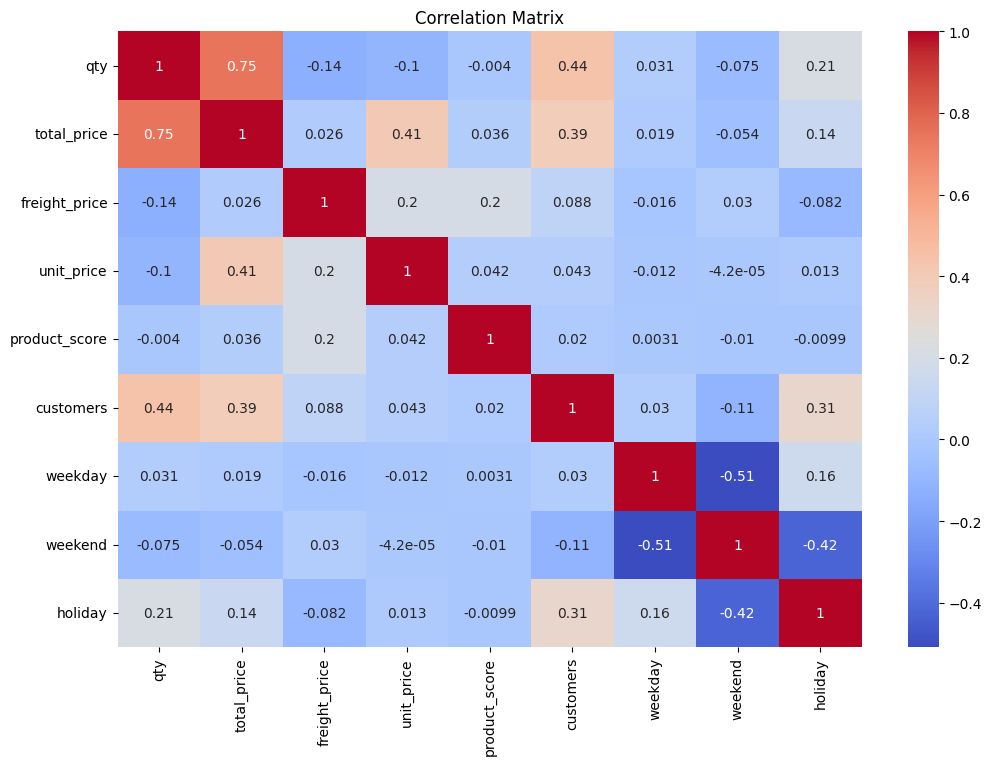

In [25]:
# Sélection des colonnes pour la matrice
subset_cols = ['qty', 'total_price', 'freight_price', 'unit_price', 'product_score', 'customers', 'weekday', 'weekend', 'holiday']
subset_df = df[subset_cols]

# Matrice de corrélation
corr_matrix = subset_df.corr()

# Affichage de la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


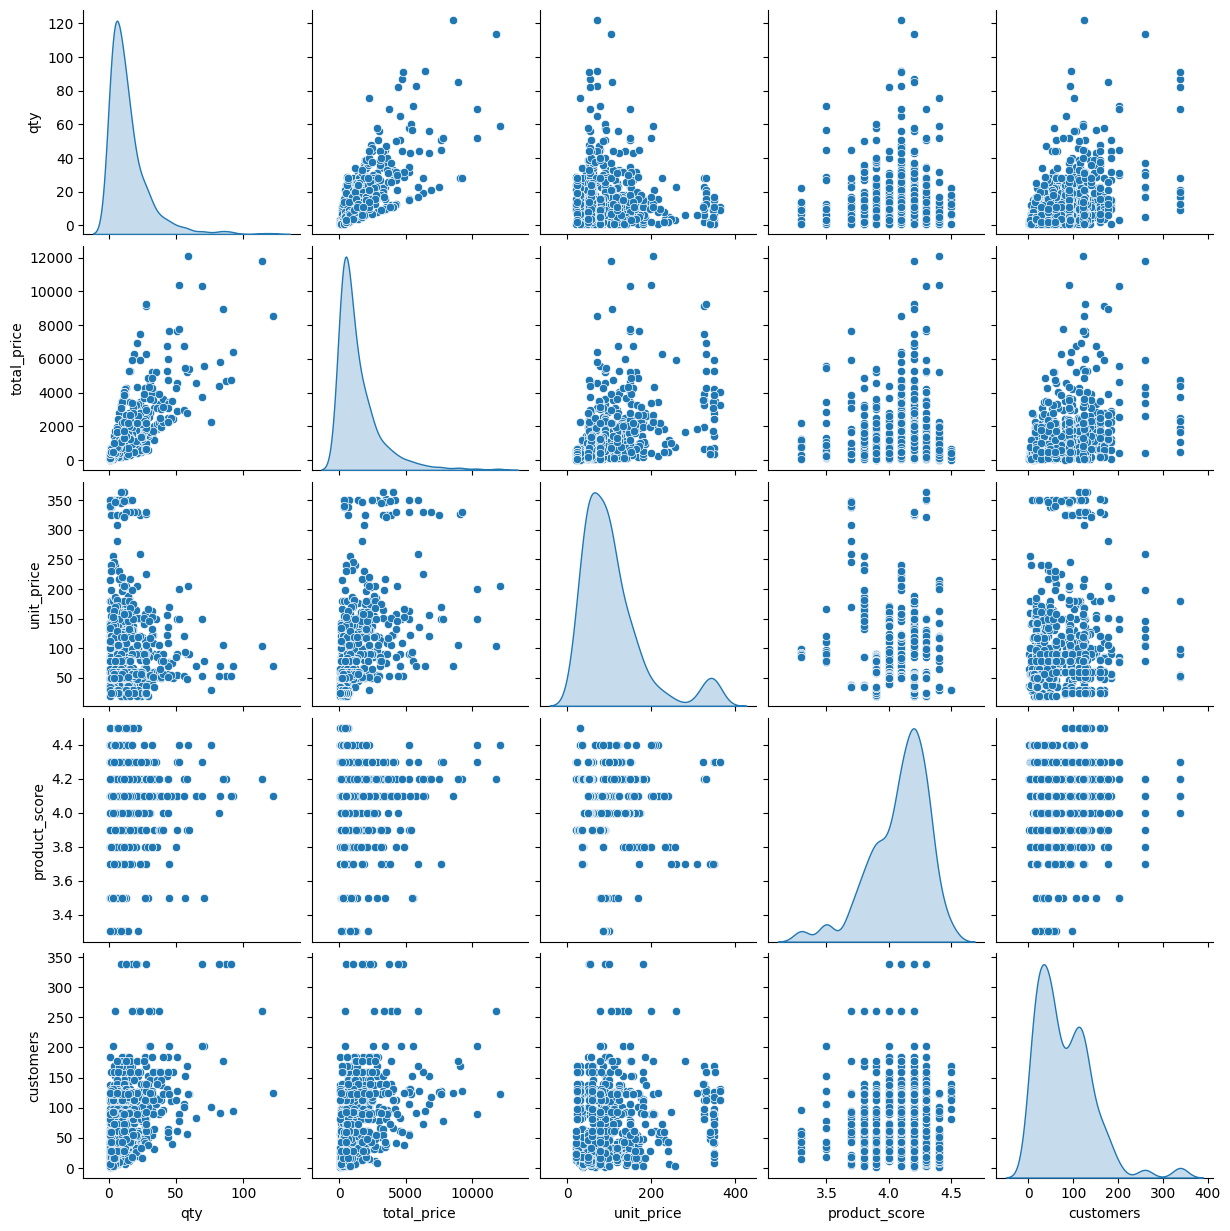

In [26]:

# Pairwise scatter plot
sns.pairplot(subset_df, vars=['qty', 'total_price', 'unit_price', 'product_score', 'customers'], diag_kind='kde')
plt.show()

# Analyse Exploratoire (EDA) - Les Graphiques Métier

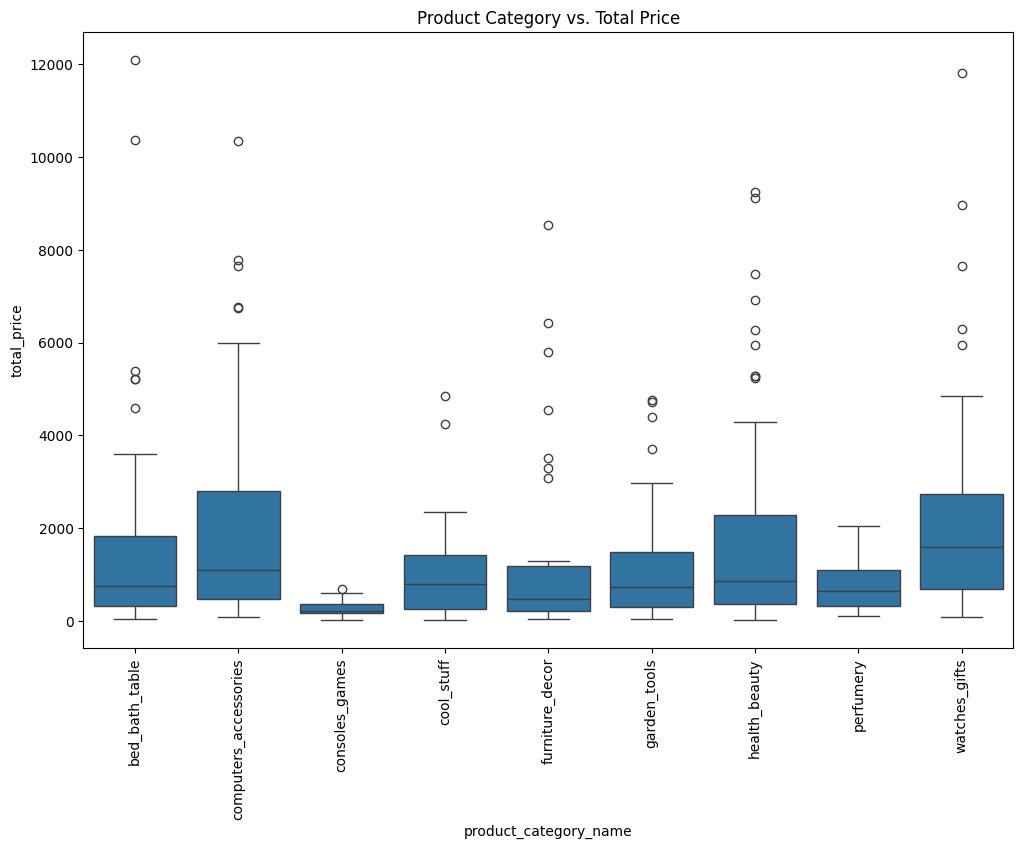

In [27]:
# Catégories vs Prix
plt.figure(figsize=(12, 8))
sns.boxplot(x='product_category_name', y='total_price', data=df)
plt.title('Product Category vs. Total Price')
plt.xticks(rotation=90)
plt.show()



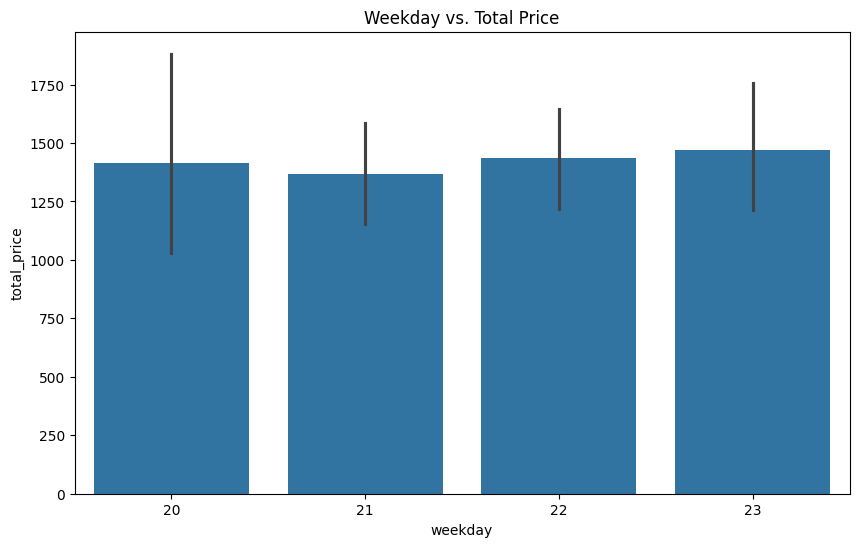

In [28]:
# Jours de la semaine vs Prix
plt.figure(figsize=(10, 6))
sns.barplot(x='weekday', y='total_price', data=df)
plt.title('Weekday vs. Total Price')
plt.show()


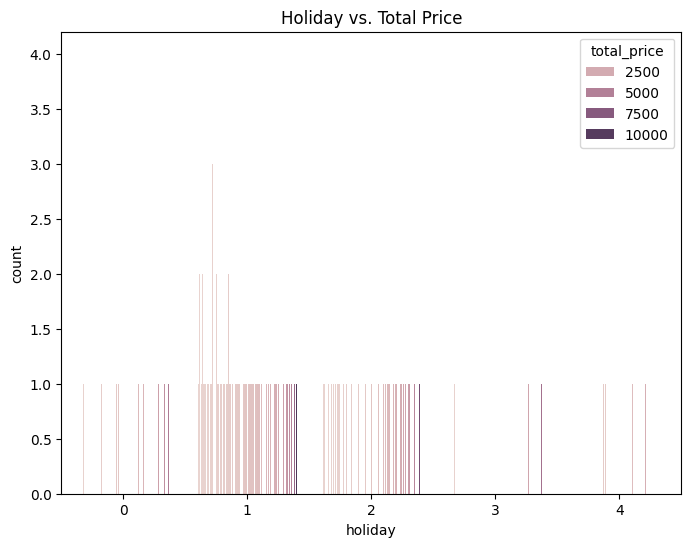

In [29]:
# Vacances vs Prix
plt.figure(figsize=(8, 6))
sns.countplot(x='holiday', data=df, hue='total_price')
plt.title('Holiday vs. Total Price')
plt.show()

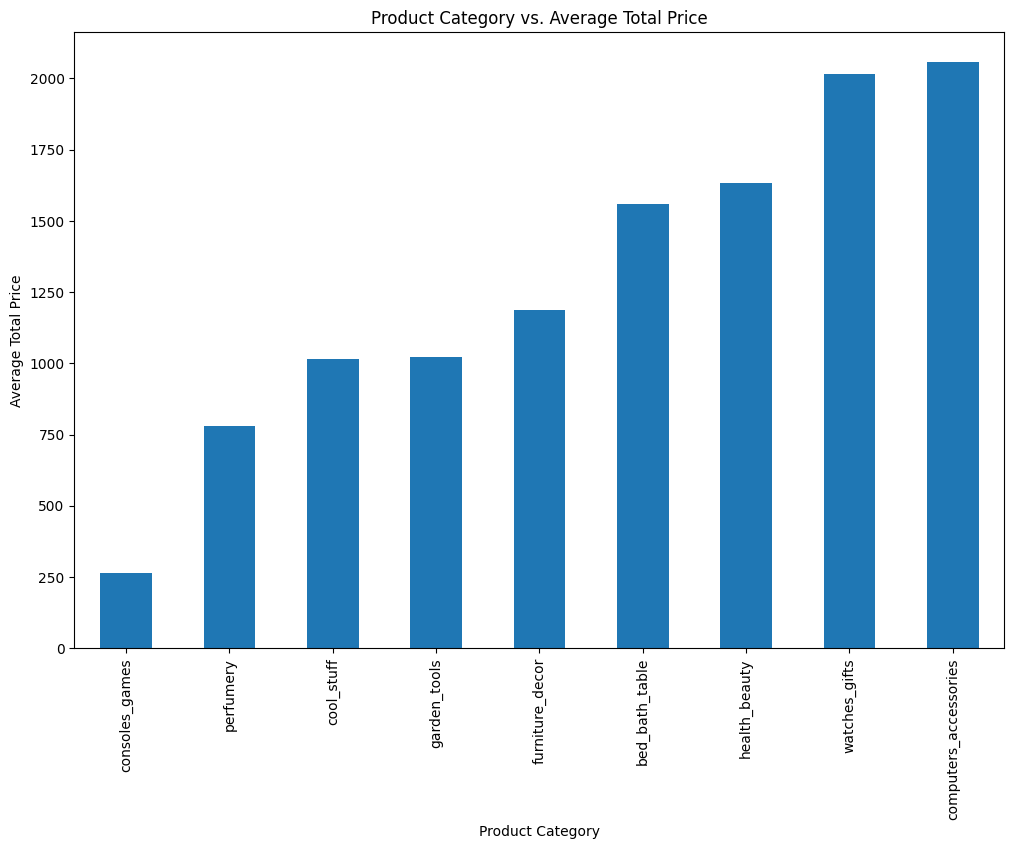

In [30]:
# Moyenne des prix par catégorie
plt.figure(figsize=(12, 8))
df.groupby('product_category_name')['total_price'].mean().sort_values().plot(kind='bar')
plt.title('Product Category vs. Average Total Price')
plt.xlabel('Product Category')
plt.ylabel('Average Total Price')
plt.xticks(rotation=90)
plt.show()

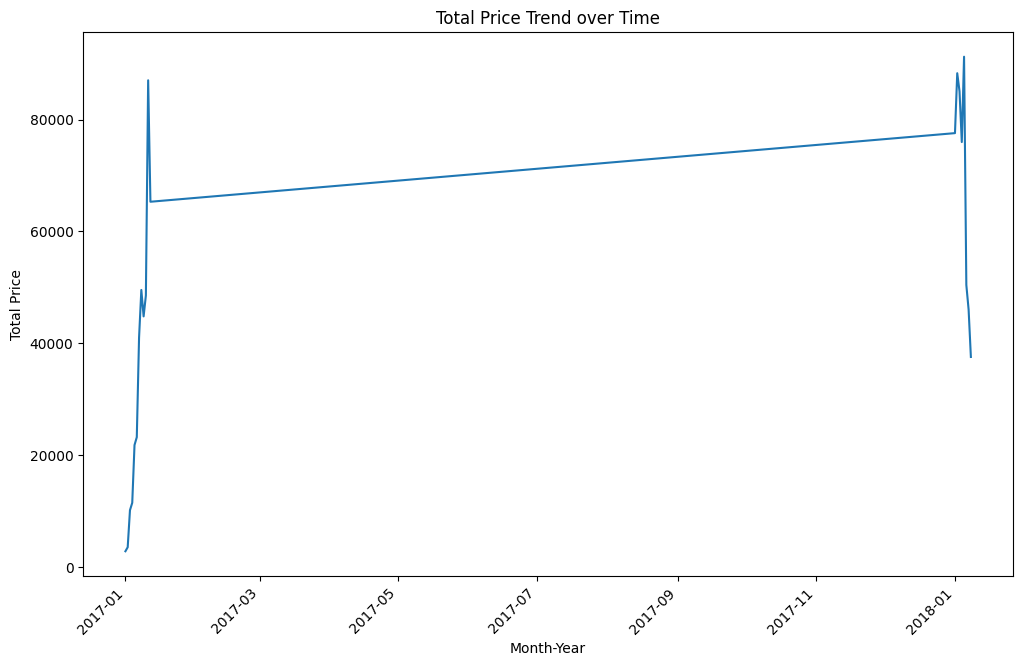

In [31]:

# Tendance des prix dans le temps
plt.figure(figsize=(12, 8))
df.groupby('month_year')['total_price'].sum().plot(kind='line')
plt.title('Total Price Trend over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Price')
plt.xticks(rotation=45)
plt.show()


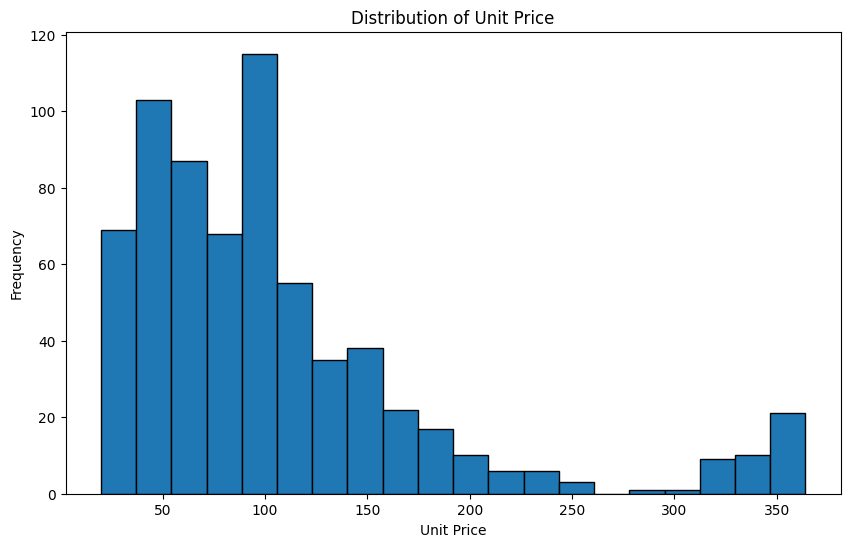

In [32]:
#  Histogramme : Distribution des prix unitaires
plt.figure(figsize=(10, 6))
plt.hist(df['unit_price'], bins=20, edgecolor='k')
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

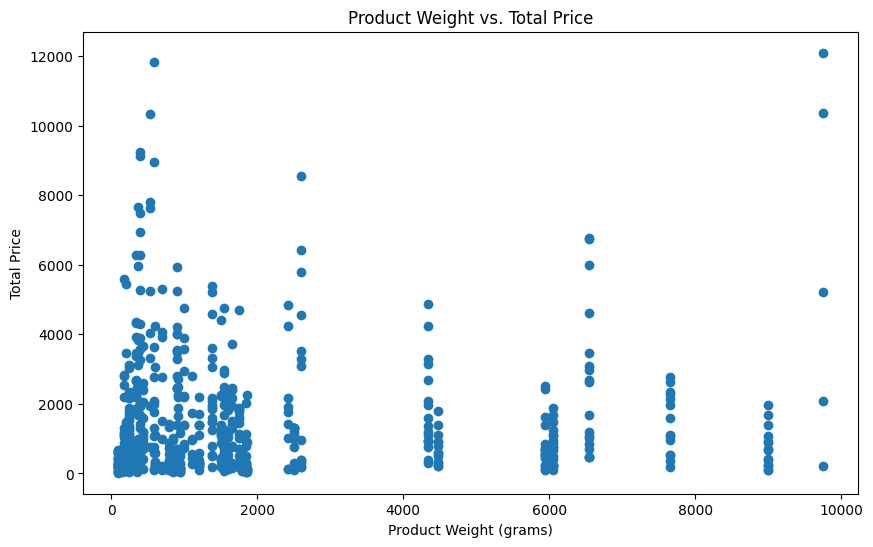

In [33]:
# Poids vs Prix
plt.figure(figsize=(10, 6))
plt.scatter(df['product_weight_g'], df['total_price'])
plt.title('Product Weight vs. Total Price')
plt.xlabel('Product Weight (grams)')
plt.ylabel('Total Price')
plt.show()

# Encodage

In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Préparation ML

In [40]:
# ENCODAGE
df_encoded = pd.get_dummies(df, columns=['product_category_name', 'weekday'])


# On applique log(1 + x) à la quantité pour écraser les pics de ventes aberrants
y_log = np.log1p(df_encoded['qty'])

cols_to_drop = ['qty', 'total_price', 'product_id', 'month_year']
X = df_encoded.drop(columns=cols_to_drop)

# On sépare X et y_log
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

# MISE À L'ÉCHELLE SÉCURISÉE
scaler = StandardScaler()
numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns

X_train[numeric_features] = X_train[numeric_features].astype(float)
X_test[numeric_features] = X_test[numeric_features].astype(float)

X_train.loc[:, numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test.loc[:, numeric_features] = scaler.transform(X_test[numeric_features])

print("Données prêtes ! Dimensions X_train :", X_train.shape)

Données prêtes ! Dimensions X_train : (540, 50)


# Les modèles

In [41]:
models = {
    "Régression Linéaire": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "Arbre de Décision": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "XGBoost": XGBRegressor(random_state=42, objective='reg:squarederror'),
    "LightGBM": LGBMRegressor(random_state=42, verbose=-1)
}

results = []
print("\nDémarrage de l'entraînement des modèles...")

for name, model in models.items():

    # On entraîne sur le Logarithme des ventes
    model.fit(X_train, y_train_log)

    # Le modèle prédit un logarithme
    y_pred_log = model.predict(X_test)

    # INVERSION : On reconvertit les prédictions en vraies quantités avec exp(x) - 1
    y_pred_real = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test_log)

    # On calcule les scores sur les VRAIES quantités
    r2 = r2_score(y_test_real, y_pred_real)
    mae = mean_absolute_error(y_test_real, y_pred_real)
    mse = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)

    results.append({
        "Modèle": name,
        "R² (Max=1)": round(r2, 4),
        "MAE (Min=0)": round(mae, 2),
        "RMSE (Min=0)": round(rmse, 2)
    })

df_results = pd.DataFrame(results).sort_values(by="R² (Max=1)", ascending=False)

print("\nClassement final des modèles :")
print("-" * 65)
print(df_results.to_string(index=False))


Démarrage de l'entraînement des modèles...

Classement final des modèles :
-----------------------------------------------------------------
             Modèle  R² (Max=1)  MAE (Min=0)  RMSE (Min=0)
           LightGBM      0.6903         5.26          9.80
            XGBoost      0.6650         5.52         10.19
  Gradient Boosting      0.6174         5.83         10.89
      Random Forest      0.6070         5.64         11.04
K-Nearest Neighbors      0.3760         7.94         13.91
  Arbre de Décision      0.2964         8.12         14.77
              Ridge      0.1344         8.56         16.39
Régression Linéaire      0.0909         8.64         16.79
              Lasso     -0.1256        10.32         18.69


# Grid Search pour trouver les meilleurs param du modèle.

In [46]:
print("\n" + "="*65)
print(" DÉMARRAGE DU GRIDSEARCH SUR LIGHTGBM")
print("="*65)

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'num_leaves': [15, 31, 50]
}

lgbm_base = LGBMRegressor(random_state=42, verbose=-1)

grid_search = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("Test des combinaisons en cours... (cela peut prendre 1 à 2 minutes)")
grid_search.fit(X_train, y_train_log)

best_lgbm = grid_search.best_estimator_

print("\n Recherche terminée !")
print("Meilleurs paramètres trouvés :", grid_search.best_params_)

y_pred_log_tuned = best_lgbm.predict(X_test)
y_pred_real_tuned = np.expm1(y_pred_log_tuned)

r2_tuned = r2_score(y_test_real, y_pred_real_tuned)
mae_tuned = mean_absolute_error(y_test_real, y_pred_real_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test_real, y_pred_real_tuned))

print("\n SCORE DU LIGHTGBM OPTIMISÉ :")
print("-" * 30)
print(f"NOUVEAU R² (GridSearch)  : {r2_tuned:.4f}")
print(f"NOUVEAU MAE              : {mae_tuned:.2f}")
print(f"NOUVEAU RMSE             : {rmse_tuned:.2f}")


 DÉMARRAGE DU GRIDSEARCH SUR LIGHTGBM
Test des combinaisons en cours... (cela peut prendre 1 à 2 minutes)
Fitting 5 folds for each of 81 candidates, totalling 405 fits

 Recherche terminée !
Meilleurs paramètres trouvés : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 15}

 SCORE DU LIGHTGBM OPTIMISÉ :
------------------------------
NOUVEAU R² (GridSearch)  : 0.7196
NOUVEAU MAE              : 5.21
NOUVEAU RMSE             : 9.33


# Exemple des prédictions

In [56]:
#  Création du tableau de comparaison
df_exemples = pd.DataFrame({
    'Ventes Réelles (Ground Truth)': y_test_real.values.round(0).astype(int),
    'Prédiction IA (LightGBM)': y_pred_real_tuned.round(0).astype(int)
})

# Calcul de l'écart
df_exemples['Écart (Erreur)'] = abs(df_exemples['Ventes Réelles (Ground Truth)'] - df_exemples['Prédiction IA (LightGBM)'])

print("\n VOICI 10 EXEMPLES DE PRÉDICTIONS DE TON MODÈLE :")
print("-" * 65)
print(df_exemples.sample(10, random_state=42).to_string(index=False))


 VOICI 10 EXEMPLES DE PRÉDICTIONS DE TON MODÈLE :
-----------------------------------------------------------------
 Ventes Réelles (Ground Truth)  Prédiction IA (LightGBM)  Écart (Erreur)
                             1                         2               1
                             4                         3               1
                             5                         5               0
                            11                        16               5
                             1                         1               0
                            28                         9              19
                            10                         9               1
                             3                         7               4
                            15                         6               9
                            36                        26              10


 Le Top des variables qui déclenchent tes ventes :
-------------------------------------------------------
            Variable  Importance (%)
           lag_price           26900
                   s           18700
       freight_price           15900
customer_score_ratio            9700
customer_photo_ratio            9500
          unit_price            9100
                 fp2            8900
                 fp3            8900
                 fp1            7600
       price_ratio_1            7500


/tmp/ipykernel_7119/2129762951.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance (%)', y='Variable', data=df_importances, palette='viridis')


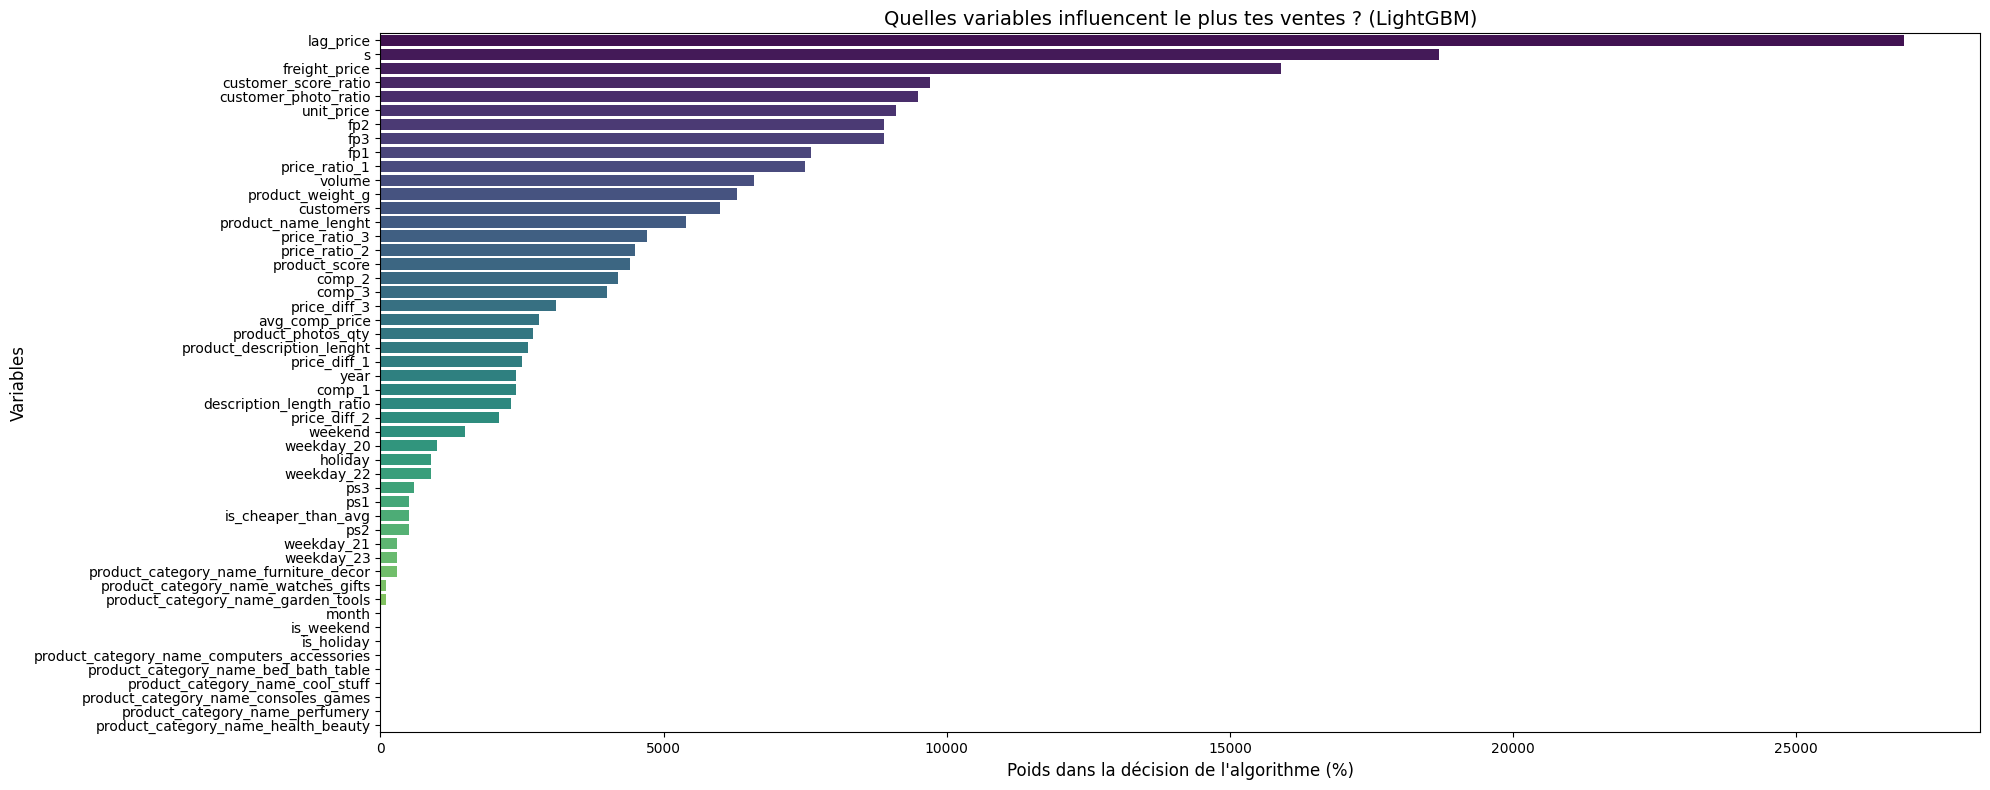

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# On récupère notre modèle champion (qui est déjà entraîné grâce à ta boucle précédente)
champion = models["LightGBM"]

# On extrait l'importance de chaque variable (la somme totale fait 1.0, soit 100%)
importances = champion.feature_importances_

# On crée un DataFrame pour lier les noms des colonnes à leur score
df_importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Importance (%)': importances * 100 # Multiplié par 100 pour une lecture en pourcentage
}).sort_values(by='Importance (%)', ascending=False)

# Affichage du top 10 des variables les plus importantes
print(" Le Top des variables qui déclenchent tes ventes :")
print("-" * 55)
print(df_importances.head(10).to_string(index=False))

# Création d'un graphique pour y voir plus clair
plt.figure(figsize=(20, 8))
sns.barplot(x='Importance (%)', y='Variable', data=df_importances, palette='viridis')
plt.title('Quelles variables influencent le plus tes ventes ? (LightGBM)', fontsize=14)
plt.xlabel("Poids dans la décision de l'algorithme (%)", fontsize=12)
plt.ylabel('Variables', fontsize=12)
plt.tight_layout()
plt.show()

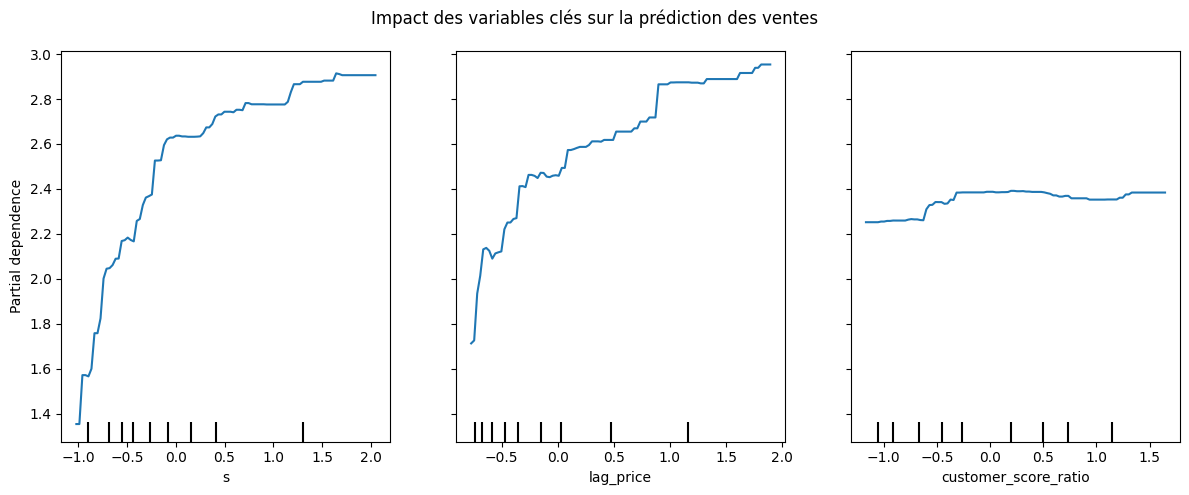

In [49]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# On choisit les variables stars à analyser
variables_a_analyser = ['s', 'lag_price', 'customer_score_ratio']

# On configure la taille du graphique
fig, ax = plt.subplots(figsize=(12, 5))

# On génère le graphique
display = PartialDependenceDisplay.from_estimator(
    estimator=champion,
    X=X_train,
    features=variables_a_analyser,
    ax=ax
)

plt.suptitle("Impact des variables clés sur la prédiction des ventes")
plt.tight_layout()
plt.show()

In [50]:
import joblib

# 1. Sauvegarde du modèle optimisé (le gagnant du GridSearch)
joblib.dump(best_lgbm, 'best_lightgbm_model.pkl')

# 2. Sauvegarde du scaler (crucial pour traiter les futures données)
joblib.dump(scaler, 'retail_scaler.pkl')


['retail_scaler.pkl']